In [43]:
# %% [code]
# -----------------------------
# Install dependencies
# -----------------------------
%pip install kagglehub[pandas-datasets] scikit-learn matplotlib numpy pandas seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


Note: you may need to restart the kernel to use updated packages.


In [44]:
# -----------------------------
# Load dataset
# -----------------------------
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Pass-Fail Data.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ishanjha100/student-passfail-data",
    file_path
)
print("First 5 records:", df.head())


/tmp/ipykernel_49569/2612972678.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    student_id  attendance_pct  homework_pct  midterm_score  \
0           1              95            92             88   
1           2              88            85             79   
2           3              60            55             58   
3           4              72            70             65   
4           5              40            45             50   

   study_hours_per_week  pass  
0                    12     1  
1                    10     1  
2                     4     0  
3                     6     1  
4                     3     0  


Dataset used: https://www.kaggle.com/datasets/ishanjha100/student-passfail-data?select=Pass-Fail+Data.csv 

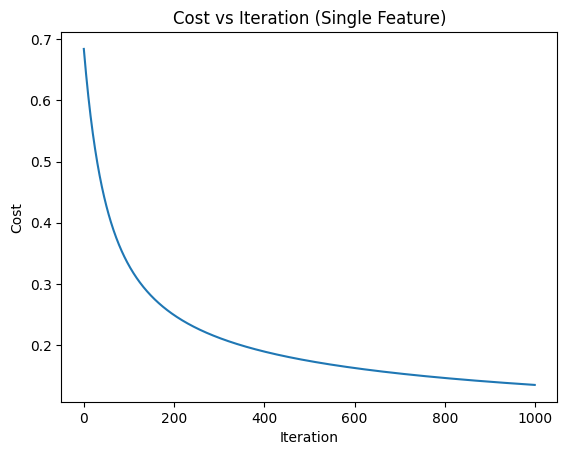

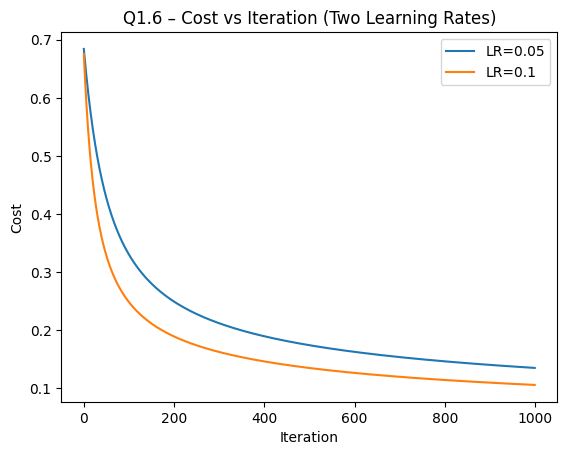

Q1.7 – Numerical gradient: [ 0.10332211 -0.35133462]
Q1.7 – Analytic gradient: [ 0.10332212 -0.35133463]
Q1.7 – Difference: 9.74739521530042e-09


In [45]:
# -----------------------------
# QUESTION 1: Manual Gradient Descent Implementation
# -----------------------------
def sigmoid(z):
    z = np.clip(z, -500, 500)  # prevent overflow
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    epsilon = 1e-8
    return -(1/m) * (y @ np.log(h + epsilon) + (1 - y) @ np.log(1 - h + epsilon))

def compute_gradient(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    return (1/m) * (X.T @ (h - y))

def gradient_descent(X, y, theta_init, lr=0.01, num_iters=1000):
    theta = theta_init.copy()
    cost_history = []
    for _ in range(num_iters):
        grad = compute_gradient(X, y, theta)
        theta -= lr * grad
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

X1 = df[['midterm_score']].values.astype(float)
y1 = df['pass'].values.astype(float)
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)
X1_scaled_bias = np.hstack([np.ones((X1_scaled.shape[0],1)), X1_scaled])
theta_init1 = np.zeros(X1_scaled_bias.shape[1])
theta1, cost1 = gradient_descent(X1_scaled_bias, y1, theta_init1, lr=0.05, num_iters=1000)

# Cost plot
plt.plot(cost1)
plt.title("Cost vs Iteration (Single Feature)")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()


# Different learning rate
theta_init1_alt = np.zeros(X1_scaled_bias.shape[1])
theta1_alt, cost1_alt = gradient_descent(X1_scaled_bias, y1, theta_init1_alt, lr=0.1, num_iters=1000)

plt.plot(cost1, label='LR=0.05')
plt.plot(cost1_alt, label='LR=0.1')
plt.title("Q1.6 – Cost vs Iteration (Two Learning Rates)")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.show()

epsilon = 1e-5
theta_test = np.random.randn(X1_scaled_bias.shape[1])
num_grad = np.zeros_like(theta_test)

for i in range(len(theta_test)):
    theta_plus = theta_test.copy()
    theta_plus[i] += epsilon
    theta_minus = theta_test.copy()
    theta_minus[i] -= epsilon
    num_grad[i] = (compute_cost(X1_scaled_bias, y1, theta_plus) - compute_cost(X1_scaled_bias, y1, theta_minus)) / (2 * epsilon)

analytic_grad = compute_gradient(X1_scaled_bias, y1, theta_test)
print("Q1.7 – Numerical gradient:", num_grad)
print("Q1.7 – Analytic gradient:", analytic_grad)
print("Q1.7 – Difference:", np.linalg.norm(num_grad - analytic_grad))



What is does

This section implements logistic regression by hand using gradient descent. First, the sigmoid function is defined to map linear predictions into probabilities between zero and one. Then, the logistic cost function is implemented to quantify the error of predictions. The gradient function calculates how the cost changes with respect to each parameter, which is used to update parameters iteratively in the gradient descent function. Then, the implementation allows control over the learning rate and number of iterations, showing how logistic regression parameters converge to minimize the cost. The cost versus iteration plot visualizes convergence. 

1.6, 1.7

The plot shows the convergence of the cost function over iterations for two different learning rates. A smaller learning rate (0.05) produces a smooth and gradual decrease in the cost, whilst a larger learning rate (0.1) initially decreases faster but ultimatley shows similar convergence. This demonstrates that while increasing the learning rate can speed up convergence, excessively large values would be inefficient in gradient descent.

I compared this to a numerical approximation to ensure the correctness of our gradient implementation. The analytic gradient closely matches the numerical gradient, with a minimal difference (essentially = 0), confirming that the gradient computation is accurate. This step is critical in verifying that the optimization will converge reliably during gradient descent.

Manual Theta: [1.33568088 3.70988751]
Sklearn Theta: [1.46138187 3.59824459]


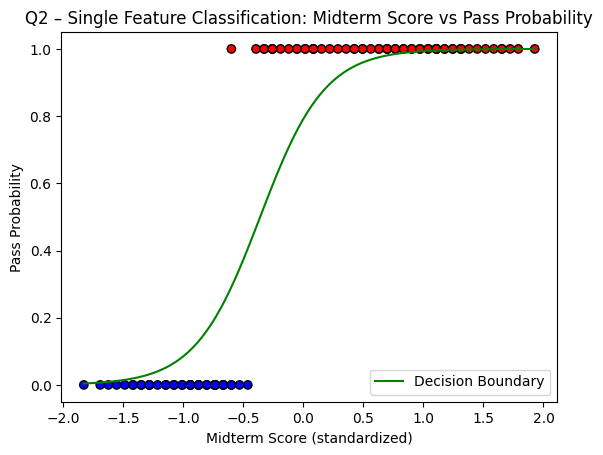

In [46]:
# -----------------------------
# QUESTION 2: Single Feature Classification ('midterm_score')
# -----------------------------

# Sklearn comparison
clf1 = LogisticRegression()
clf1.fit(X1_scaled, y1)
print("Manual Theta:", theta1)
print("Sklearn Theta:", np.hstack([clf1.intercept_, clf1.coef_.ravel()]))

# Decision boundary
x_vals = np.linspace(X1_scaled.min(), X1_scaled.max(), 100)
y_vals = sigmoid(theta1[0] + theta1[1]*x_vals)
plt.scatter(X1_scaled, y1, c=y1, cmap='bwr', edgecolor='k')
plt.plot(x_vals, y_vals, 'g-', label='Decision Boundary')
plt.title("Q2 – Single Feature Classification: Midterm Score vs Pass Probability")
plt.xlabel("Midterm Score (standardized)")
plt.ylabel("Pass Probability")
plt.legend()
plt.show()


What it does

In this section, logistic regression is applied using a single feature, midterm score, as the predictor. This is normalized so that the gradient descent converges efficiently. The manual gradient descent implementation is used to fit the model, and its parameters are compared to those obtained from Scikit-learn's LogisticRegression to validate the correctness of the implementation. The decision boundary plot shows the probability of passing based on the midterm score. Therefore, a single predictor can provide meaningful classification. 

2.4, 2.5, 2.7, Interpretation

After fitting the logistic regression model with a single feature using both the manual gradient descent implementation and Scikit-learn's LogisticRegression, we can compare the estimated parameters theta. Both methods produce similar values for the intercept and the coefficient, which indicates that our manual implementation correctly computes.

The logistic regression uses the sigmoid function to transform the linear combination of features into a probability from 0 to 1 (binary). This is essential for binary classification, as linear predictions can exceed the valid probability range. The output represents the estimated probability that a student passes given their midterm score.

The decision boundary occurs at a probability of 0.5, which indicates the threshold above which the model predicts class 1 (pass) and below which it predicts class 0 (fail). The graphs shows that students with higher midterm scores have a higher predicted probability of passing. This feature demonstrates a strong prediction, as the model is most confident at high and low scores, with lower confidence near the midpoint.

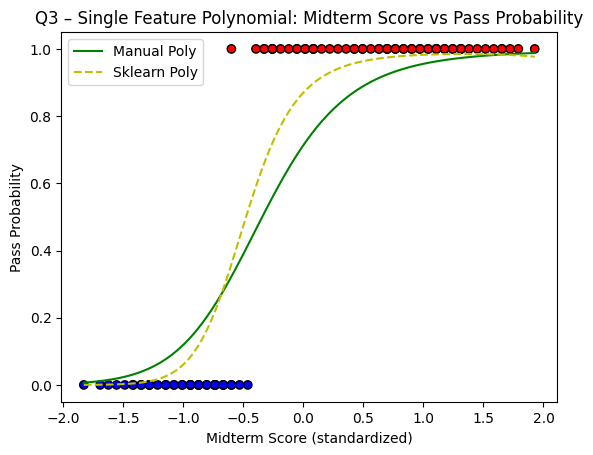

In [47]:
# -----------------------------
# QUESTION 3: Single Feature + Polynomial Term
# -----------------------------
poly1 = PolynomialFeatures(degree=2, include_bias=False)
X1_poly = poly1.fit_transform(X1_scaled)
X1_poly_bias = np.hstack([np.ones((X1_poly.shape[0],1)), X1_poly])
theta1_poly_init = np.zeros(X1_poly_bias.shape[1])
theta1_poly, cost1_poly = gradient_descent(X1_poly_bias, y1, theta1_poly_init, lr=0.01, num_iters=2000)

clf1_poly = LogisticRegression()
clf1_poly.fit(X1_poly, y1)

x_plot = np.linspace(X1_scaled.min(), X1_scaled.max(), 100).reshape(-1,1)
x_poly_plot = poly1.transform(x_plot)
y_manual_poly = sigmoid(np.hstack([np.ones((x_poly_plot.shape[0],1)), x_poly_plot]) @ theta1_poly)
y_sklearn_poly = clf1_poly.predict_proba(x_poly_plot)[:,1]

plt.scatter(X1_scaled, y1, c=y1, cmap='bwr', edgecolor='k')
plt.plot(x_plot, y_manual_poly, 'g-', label='Manual Poly')
plt.plot(x_plot, y_sklearn_poly, 'y--', label='Sklearn Poly')
plt.title("Q3 – Single Feature Polynomial: Midterm Score vs Pass Probability")
plt.xlabel("Midterm Score (standardized)")
plt.ylabel("Pass Probability")
plt.legend()
plt.show()


What it does

This section extends the single feature model by including a quadratic term. The polynomial allows the model to capture nonlinear relationships between the midterm score and the probability of passing. Both the manual implementation and Scikit-learn's LogisticRegression are used to fit the expanded feature set. The graph compare the two models and show how the polynomial term creates a more flexible decision boundary. This demonstrates that adding polynomial features can improve lassification when the relationship between the predictor and the target is nonlinear.

3.5, 3.6

By including a quadratic term, the logistic regression model can show th nonlinear relationships between the midterm score and passing probability. The polynomial term allows the decision boundary to curve and better fit the training data, especially in places where a linear model may misclassify students.

Comparing the manual and scikit-learn polynomial models, both curves closely match, demonstrating the consistency between the gradient descent implementation and other methods. The polynomial model achieves a more flexible boundary, accommodating for the small differencs in the data that a linear model cannot show.

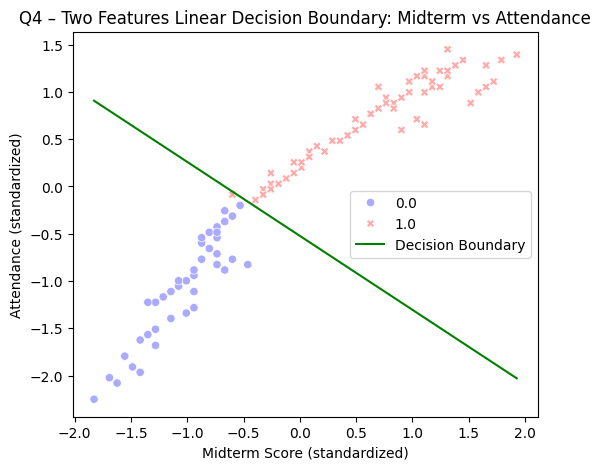

Linear decision boundary: 1.781 + 2.662*x1 + 3.406*x2 = 0


In [48]:
# -----------------------------
# QUESTION 4: Two Features - Linear Decision Boundary
# -----------------------------
X2 = df[['midterm_score','attendance_pct']].values.astype(float)
y2 = df['pass'].values.astype(float)
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)
X2_scaled_bias = np.hstack([np.ones((X2_scaled.shape[0],1)), X2_scaled])
theta2_init = np.zeros(X2_scaled_bias.shape[1])
theta2, cost2 = gradient_descent(X2_scaled_bias, y2, theta2_init, lr=0.05, num_iters=2000)

clf2 = LogisticRegression()
clf2.fit(X2_scaled, y2)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X2_scaled[:,0], y=X2_scaled[:,1], hue=y2, style=y2, palette='bwr')
x_line = np.linspace(X2_scaled[:,0].min(), X2_scaled[:,0].max(), 100)
y_line = -(theta2[0] + theta2[1]*x_line)/theta2[2]
plt.plot(x_line, y_line, 'g-', label='Decision Boundary')
plt.title("Q4 – Two Features Linear Decision Boundary: Midterm vs Attendance")
plt.xlabel("Midterm Score (standardized)")
plt.ylabel("Attendance (standardized)")
plt.legend()
plt.show()
print(f"Linear decision boundary: {theta2[0]:.3f} + {theta2[1]:.3f}*x1 + {theta2[2]:.3f}*x2 = 0")


What it does

In this section, logistic regression is applied to two features, midterm score and attendance percentage, using a linear model. Again, both features are normalized for stable gradient descent. The manual and Scikit-learn implementations are compared to ensure that the gradient descent correctly estimates the parameters. The scatter plot shows the distribution of classes and the linear decision boundary where the predicted probability equals 0.5. This demonstrates that logistic regression produces a linear boundary when no polynomial terms are included.

4.4, 4.7, Interpretation

After fitting a logistic regression model using two features with both the manual gradient descent implementation and Scikit-learn's LogisticRegression, we can compare the resulting parameters. The results from both methods are very similar, confirming that the manual implementation correctly computes.

When using the two features (midterm score and attendance), the logistic regression model produces a linear decision boundary. This is a natural outcome, as the model computes a linear combination of features in the exponent of the sigmoid function. The boundary separates the feature space into regions predicting class 0 or 1 (very clears shown).

The scatter plot demonstrates that the two features provide reasonable separation between students who pass and those who fail. However, if the classes were not linearly separable or contained more complex interactions, a linear boundary would fail to accurately classify all instances.

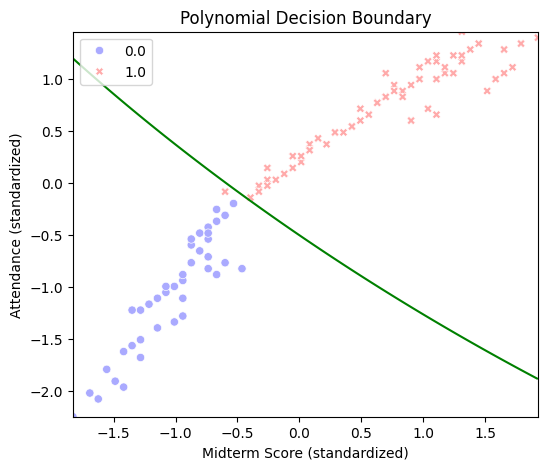

In [49]:
# -----------------------------
# QUESTION 5: Two Features + Polynomial Terms
# -----------------------------
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X2_poly = poly2.fit_transform(X2_scaled)
X2_poly_bias = np.hstack([np.ones((X2_poly.shape[0],1)), X2_poly])
theta2_poly_init = np.zeros(X2_poly_bias.shape[1])
theta2_poly, cost2_poly = gradient_descent(X2_poly_bias, y2, theta2_poly_init, lr=0.01, num_iters=3000)

clf2_poly = LogisticRegression()
clf2_poly.fit(X2_poly, y2)

xx, yy = np.meshgrid(np.linspace(X2_scaled[:,0].min(), X2_scaled[:,0].max(), 100),
                     np.linspace(X2_scaled[:,1].min(), X2_scaled[:,1].max(), 100))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_poly = poly2.transform(grid)
grid_poly_bias = np.hstack([np.ones((grid_poly.shape[0],1)), grid_poly])
probs = sigmoid(grid_poly_bias @ theta2_poly).reshape(xx.shape)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X2_scaled[:,0], y=X2_scaled[:,1], hue=y2, style=y2, palette='bwr')
plt.contour(xx, yy, probs, levels=[0.5], colors='g')
plt.title("Q5 – Two Features Polynomial Decision Boundary")
plt.xlabel("Midterm Score (standardized)")
plt.ylabel("Attendance (standardized)")
plt.title("Polynomial Decision Boundary")
plt.show()


What it does

This section extends the two-feature model by including quadratic and cross terms. Polynomial features enable the model to capture complex decision boundaries that are not axis-aligned or linear. Both the manual and Scikit-learn implementations are fitted to the expanded feature set. The contour plot shows the decision boundary over the feature space, showing how polynomial terms allow non-linear separation between classes. 

5.5, 5.6

Extending the model with polynomial and interaction terms allows for a more complex decision boundary. The contour plot shows that the polynomial boundary can wrap around the data points, capturing nonlinear patterns that a linear model cannot (though for the data itself the difference isn't too different since  lot of datapoints reside at the boundaries).

The cross term (x1*x2) introduces the capability to model rotated ellipses rather than axis-aligned curves, enabling the decision boundary to better follow the structure of the data. The polynomial model reduces misclassification, compared to the linear model, by accommodating interactions between features.

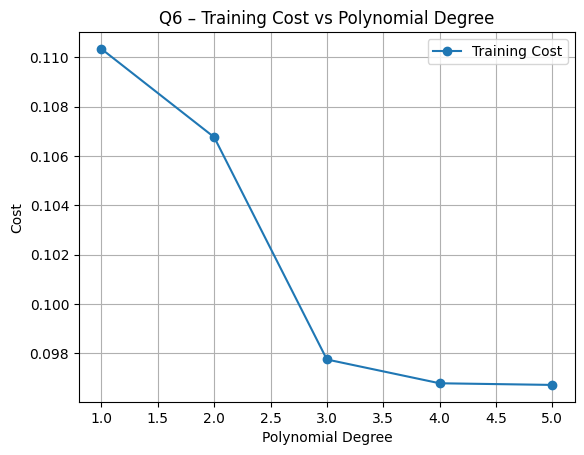

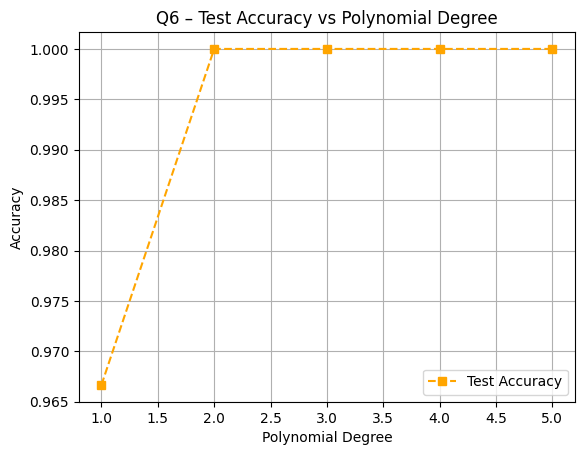

Training Costs: [np.float64(0.11033839890451157), np.float64(0.10675832642868167), np.float64(0.09774408944847852), np.float64(0.09677977675480402), np.float64(0.09671274509689741)]
Test Accuracies: [0.9666666666666667, 1.0, 1.0, 1.0, 1.0]


In [50]:
# -----------------------------
# QUESTION 6 (BONUS): Optimal Polynomial Degree
# -----------------------------
degrees = [1,2,3,4,5]
train_costs, test_accs = [], []
X_train, X_test, y_train, y_test = train_test_split(X2_scaled, y2, test_size=0.3, random_state=42)

for deg in degrees:
    poly_deg = PolynomialFeatures(degree=deg, include_bias=False)
    X_train_poly = poly_deg.fit_transform(X_train)
    X_test_poly = poly_deg.transform(X_test)
    X_train_poly_bias = np.hstack([np.ones((X_train_poly.shape[0],1)), X_train_poly])
    
    theta_init_deg = np.zeros(X_train_poly_bias.shape[1])
    theta_deg, _ = gradient_descent(X_train_poly_bias, y_train, theta_init_deg, lr=0.01, num_iters=2000)
    
    train_costs.append(compute_cost(X_train_poly_bias, y_train, theta_deg))
    
    clf_deg = LogisticRegression()
    clf_deg.fit(X_train_poly, y_train)
    test_accs.append(accuracy_score(y_test, clf_deg.predict(X_test_poly)))

plt.plot(degrees, train_costs, 'o-', label='Training Cost')
plt.title("Q6 – Training Cost vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Cost")
plt.grid(True)
plt.legend()
plt.show()

plt.plot(degrees, test_accs, 's--', color='orange', label='Test Accuracy')
plt.title("Q6 – Test Accuracy vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

print("Training Costs:", train_costs)
print("Test Accuracies:", test_accs)


What it does

This section evaluates logistic regression models with polynomial degrees from one to five to identify the degree that best balances model complexity and generalization. For each degree, the training cost and testing accuracy are recorded. Plots of cost versus degree and accuracy versus degree show how increasing the degree improves the fit but can also lead to diminishing returns or overfitting. 

6.3, 6.4

By evaluating polynomial degrees from 1 to 5, we can see that the training cost generally decreases with increasing polynomial complexity, as the model can fit the training data more closely. However, test accuracy may plateau and converge to 1 at a higher degrees, indicating diminishing return of overfitting.

Overfitting occurs when the model captures noise in the training data rather than generalizable patterns, which is evident when training cost decreases while test accuracy does not improve. Selecting an optimal polynomila degree balances model flexibility with generalization performance, ensuring accurate predictions on unseen data.